# Clustering Analysis - Wine Chemical Analysis Project

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
from sklearn.datasets import load_wine
wine = load_wine(as_frame = True)
df = wine.frame
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [63]:
df.info()
print("Shape of dataset:",df.shape)

<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  class           

In [13]:
df.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


#### Data Cleaning

In [20]:
print("Number of duplicate values:",df.duplicated().sum())


Number of duplicate values: 0


In [18]:
df = df.rename(columns = {'target' : 'class'})
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,class
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


#### Feature and Class Separation

In [24]:
X = df.drop('class',axis = 1)
y = df['class']

## Exploratory Data Analysis

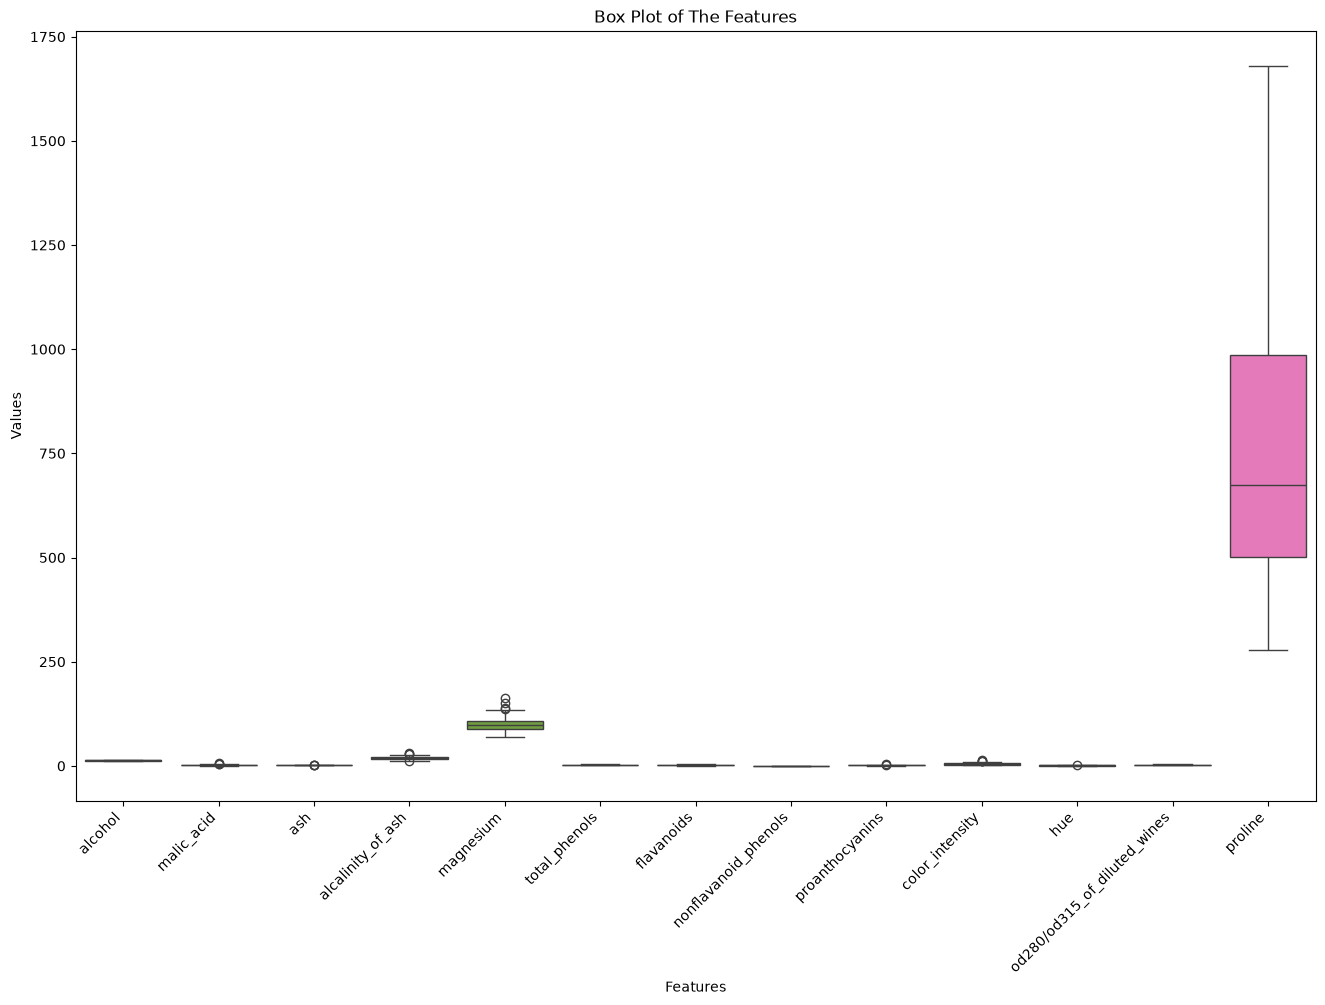

In [25]:
# Before Scaling
plt.figure(figsize = (16,10))
sns.boxplot(data = X)
plt.xticks(rotation = 45, ha = 'right')
plt.title("Box Plot of The Features")
plt.xlabel("Features")
plt.ylabel("Values")
plt.show()

In [26]:
# Check for outliers
Q1 = X.quantile(0.25)
Q3 = X.quantile(0.75)
IQR = Q3 - Q1
outliers = ((X< (Q1-1.5*IQR))|
            (X> (Q3+1.5*IQR))).sum()
outliers.sort_values(ascending = False)

magnesium                       4
alcalinity_of_ash               4
color_intensity                 4
malic_acid                      3
ash                             3
proanthocyanins                 2
hue                             1
alcohol                         0
total_phenols                   0
nonflavanoid_phenols            0
flavanoids                      0
od280/od315_of_diluted_wines    0
proline                         0
dtype: int64

 Potential Outliers were identified.But the number of outliers were small across the features

#### Multicollinearity check

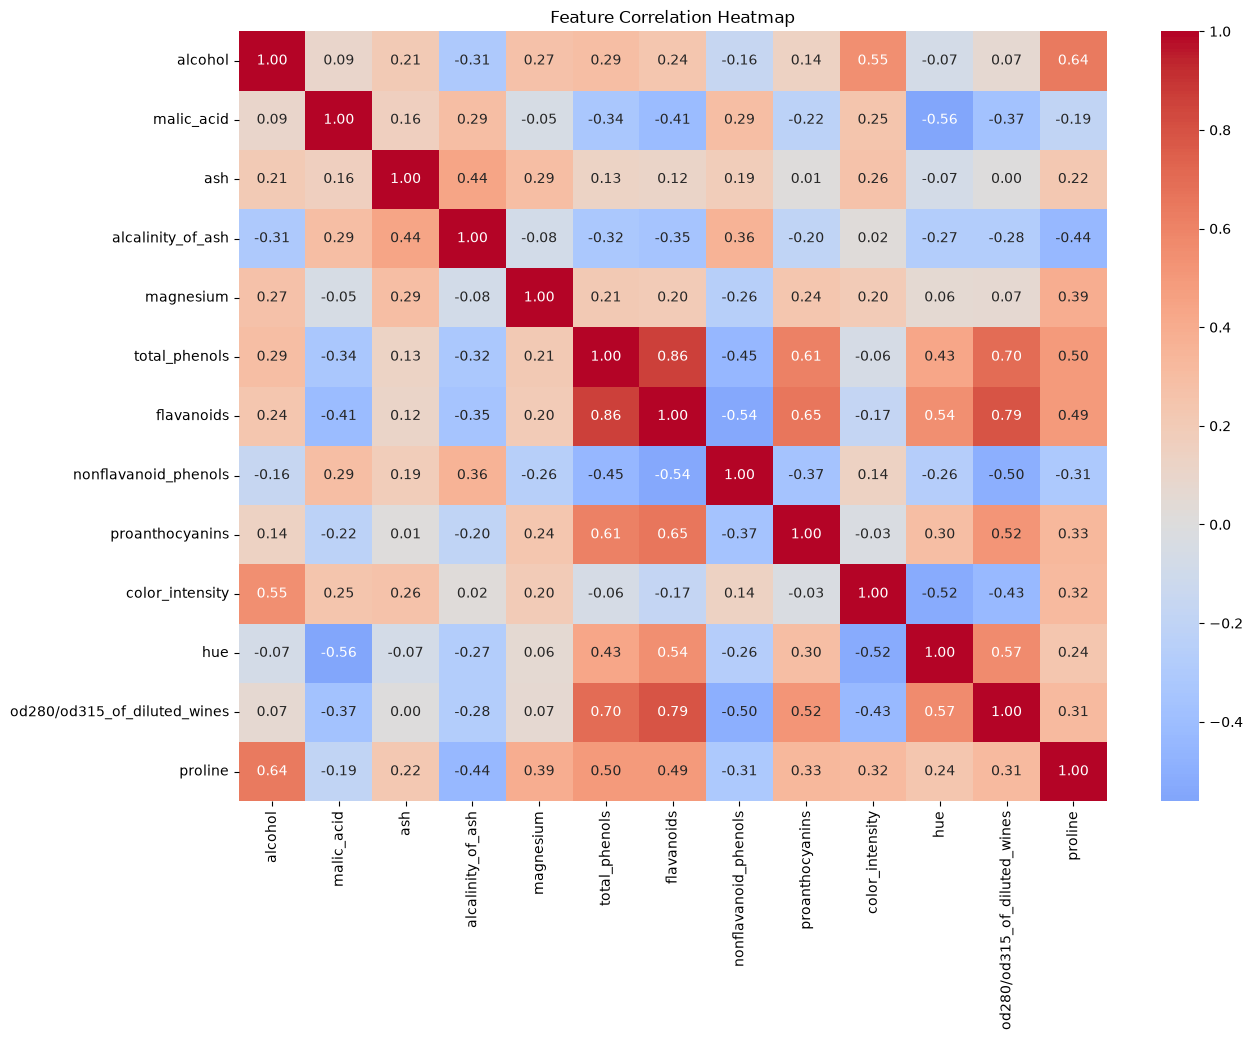

In [30]:
plt.figure(figsize=(14, 10))
corr = X.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap")
plt.show()


#### Scaling the data

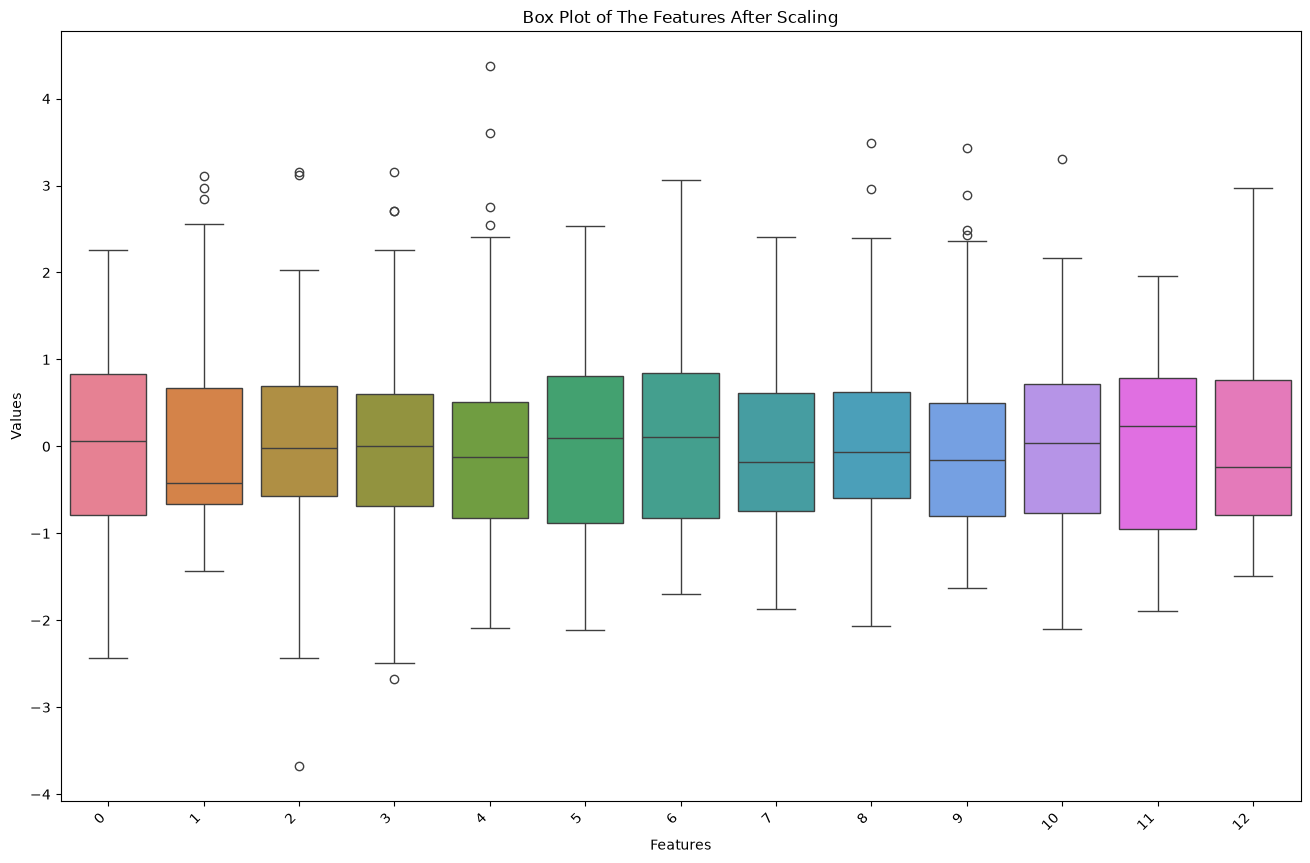

In [32]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
data_scaled = scaler.fit_transform(X)

plt.figure(figsize = (16,10))
sns.boxplot(data = data_scaled)
plt.xticks(rotation = 45, ha = 'right')
plt.title("Box Plot of The Features After Scaling")
plt.xlabel("Features")
plt.ylabel("Values")
plt.show()

#### Number of clusters for K-means

1. Elbow Method

K=2, Inertia=1658.76
K=3, Inertia=1277.93
K=4, Inertia=1175.43
K=5, Inertia=1109.51
K=6, Inertia=1046.00
K=7, Inertia=981.60
K=8, Inertia=935.20
K=9, Inertia=889.89
K=10, Inertia=845.90


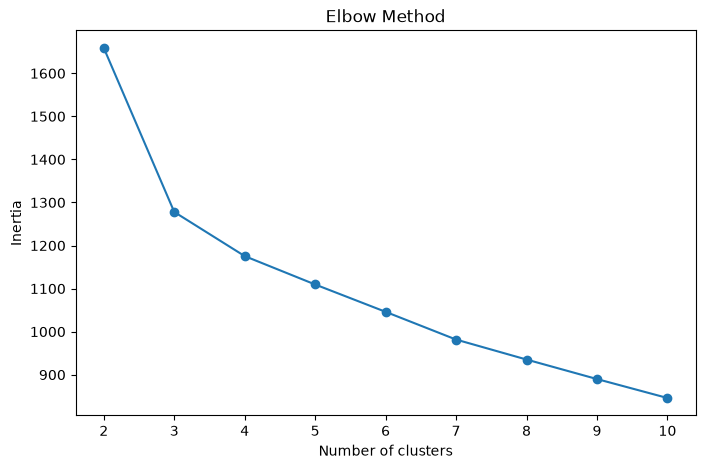

In [35]:
from sklearn.cluster import KMeans

inertia = []
for k in range(2,11):
    kmean = KMeans(n_clusters = k, random_state = 42, n_init =10)
    kmean.fit(data_scaled)
    inertia.append(kmean.inertia_)
    print(f"K={k}, Inertia={kmean.inertia_:.2f}")
plt.figure(figsize = (8,5))
plt.plot(range(2,11),inertia,marker = 'o')
plt.title("Elbow Method")
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.show()

After K = 3 the curve becomes flatter.So the elbow appears to be around K = 3

2. Silhouette Score

    K  silhouette_scores
1   3           0.284859
2   4           0.260170
0   2           0.259317
4   6           0.237167
5   7           0.203628
3   5           0.201619
6   8           0.157014
7   9           0.149882
8  10           0.143638


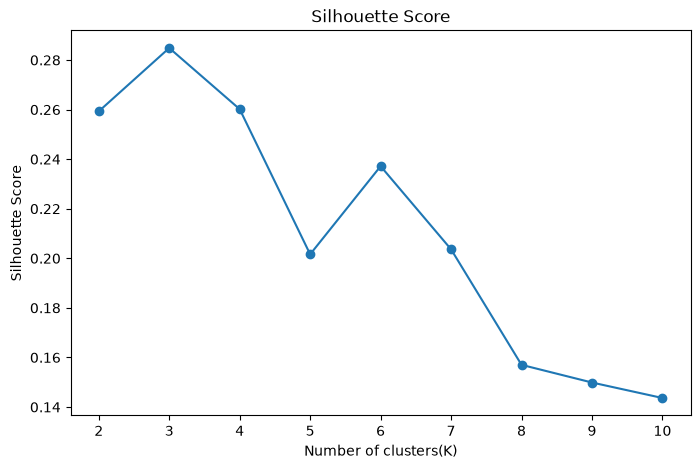

In [43]:
from sklearn.metrics import silhouette_score

silhouette_scores = []
for k in range(2,11):
    kmean = KMeans(n_clusters = k,random_state = 42,n_init =10)
    labels = kmean.fit_predict(data_scaled)
    score = silhouette_score(data_scaled, labels)
    silhouette_scores.append(score)
result = pd.DataFrame({
    'K'                :range(2,11),
    'silhouette_scores': silhouette_scores })
result = result.sort_values('silhouette_scores',ascending = False)
print(result)

plt.figure(figsize = (8,5))
plt.plot(range(2,11),silhouette_scores,marker = 'o')
plt.title("Silhouette Score")
plt.xlabel("Number of clusters(K)")
plt.ylabel("Silhouette Score")
plt.show()


Highest Silhouette score is 0.284859 for K = 3
#### K - Means Model with Number of Clusters = 3

In [46]:
kmean = KMeans(n_clusters = 3,random_state = 42, n_init = 10)
clusters = kmean.fit_predict(data_scaled)

X['Clusters'] = clusters
X.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,Clusters
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,2
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,2
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,2
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,2
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,2


In [48]:
X['Clusters'].value_counts()

Clusters
0    65
2    62
1    51
Name: count, dtype: int64

In [50]:
X.groupby('Clusters').mean()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
Clusters,,,,,,,,,,,,,
0,12.250923,1.897385,2.231231,20.063077,92.738462,2.247692,2.050000,0.357692,1.624154,2.973077,1.062708,2.803385,510.169231
1,13.134118,3.307255,2.417647,21.241176,98.666667,1.683922,0.818824,0.451961,1.145882,7.234706,0.691961,1.696667,619.058824
2,13.676774,1.997903,2.466290,17.462903,107.967742,2.847581,3.003226,0.292097,1.922097,5.453548,1.065484,3.163387,1100.225806


#### PCA -Feature Reduction for Visualization

In [52]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
data_pca = pca.fit_transform(data_scaled)
pca_X = pd.DataFrame(data_pca[:,:2], columns = ['PC1','PC2'])
pca_X['Clusters'] = clusters
pca_X.head()

,PC1,PC2,Clusters
0,3.316751,1.443463,2
1,2.209465,-0.333393,2
2,2.516740,1.031151,2
3,3.757066,2.756372,2
4,1.008908,0.869831,2


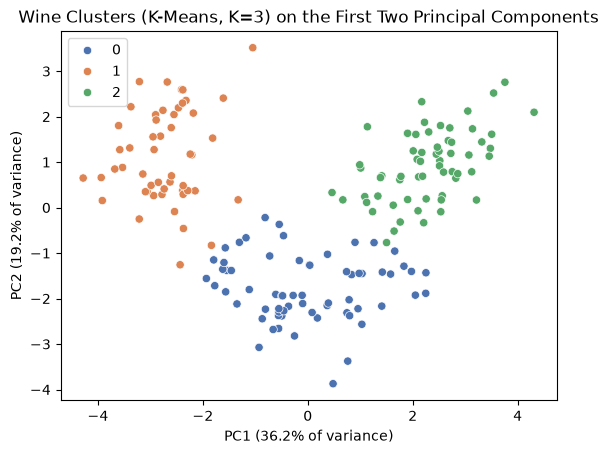

In [60]:
sns.scatterplot(data = pca_X, x = 'PC1', y= 'PC2',hue = clusters,palette = 'deep')
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} of variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} of variance)")
plt.title("Wine Clusters (K-Means, K=3) on the First Two Principal Components")
plt.show()

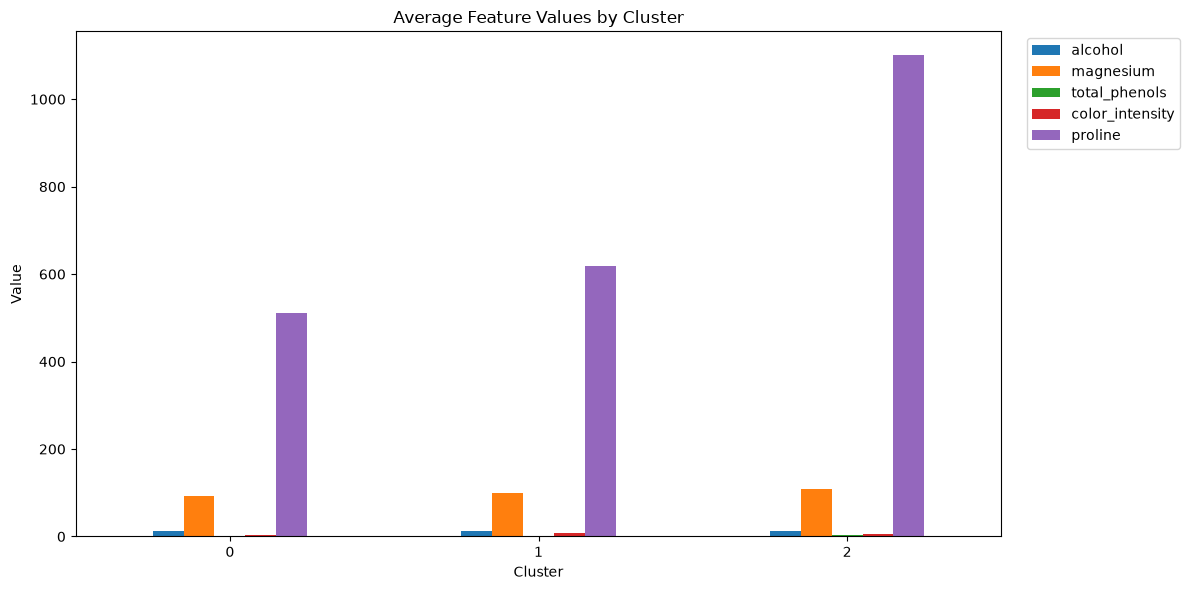

In [57]:
key_features = ['alcohol','magnesium','total_phenols','color_intensity','proline']
cluster_profile = X.groupby('Clusters').mean(numeric_only=True).round(1)
cluster_profile[key_features].plot(kind='bar', figsize=(12, 6))
plt.title("Average Feature Values by Cluster")
plt.ylabel("Value")
plt.xlabel("Cluster")
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

#### Validation of the Clusters
K-Means never saw the wine class labels, so they can be used afterwards as an independent check. 
Test stability across random seeds, per-cluster tightness, and whether scaling mattered.

True class   0   1   2
Cluster               
0            0  65   0
1            0   3  48
2           59   3   0 

Purity = 0.966 | Adjusted Rand Index = 0.897 | NMI = 0.876
Stability over 20 seeds: minimum ARI vs final clustering = 0.982

Mean silhouette per cluster:
0    0.177
1    0.351
2    0.343
Points with negative silhouette: 7 of 178

ARI vs true class: scaled = 0.897 | unscaled = 0.371
Silhouette:        scaled = 0.285 | unscaled = 0.571


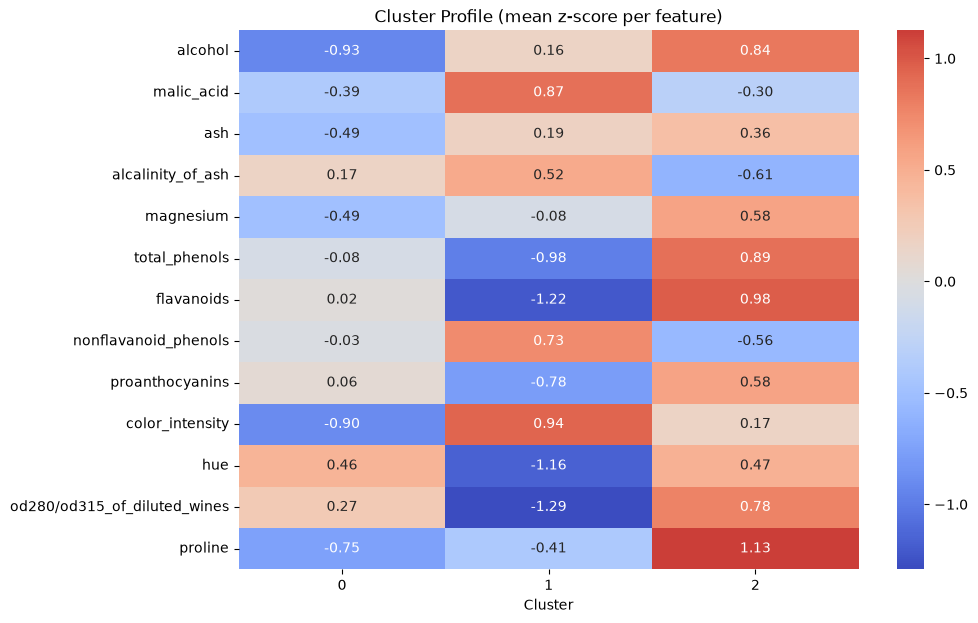

In [61]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, silhouette_samples

features = X.drop(columns="Clusters")          # X now carries the cluster labels, so drop them for any re-fit

# 1. External validation: compare clusters with the known wine class (never used for clustering)
ct = pd.crosstab(clusters, y, rownames=["Cluster"], colnames=["True class"])
print(ct, "\n")
purity = ct.max(axis=1).sum() / len(y)
print(f"Purity = {purity:.3f} | Adjusted Rand Index = {adjusted_rand_score(y, clusters):.3f} | NMI = {normalized_mutual_info_score(y, clusters):.3f}")

# 2. Stability: re-fit with 20 different random seeds and compare with the final clustering
aris = [adjusted_rand_score(clusters, KMeans(n_clusters=3, random_state=s, n_init=10).fit_predict(data_scaled)) for s in range(20)]
print(f"Stability over 20 seeds: minimum ARI vs final clustering = {min(aris):.3f}")

# 3. Cluster tightness: silhouette per cluster
sil = silhouette_samples(data_scaled, clusters)
print("\nMean silhouette per cluster:")
print(pd.Series(sil).groupby(clusters).mean().round(3).to_string())
print(f"Points with negative silhouette: {(sil < 0).sum()} of {len(sil)}")

# 4. Does scaling matter? Same K-means on the raw, unscaled features
raw_labels = KMeans(n_clusters=3, random_state=42, n_init=10).fit_predict(features.values)
print(f"\nARI vs true class: scaled = {adjusted_rand_score(y, clusters):.3f} | unscaled = {adjusted_rand_score(y, raw_labels):.3f}")
print(f"Silhouette:        scaled = {silhouette_score(data_scaled, clusters):.3f} | unscaled = {silhouette_score(features.values, raw_labels):.3f}")

# 5. Cluster profile in standardised units (comparable across features, unlike the raw-unit bar chart above)
z_profile = pd.DataFrame(data_scaled, columns=features.columns).groupby(clusters).mean()
plt.figure(figsize=(10, 7))
sns.heatmap(z_profile.T, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Cluster Profile (mean z-score per feature)")
plt.xlabel("Cluster")
plt.show()

## Project Summary

**1. Objective and data**
- Group wines into natural segments using their chemistry, with no labels used during clustering (unsupervised learning).
- The data is the UCI Wine dataset: **178 wines, 13 chemical measurements**, no missing values and no duplicates.
- The known wine class (59 / 71 / 48 wines) was held back and used only afterwards to validate the clusters.

**2. Data preparation**
- The features sit on very different scales (for example proline averages about 747 while hue averages about 0.96), so all features were **standardised** before clustering.
- An IQR check flagged only a few outliers per feature (17 rows, about 10%, with at least one). They were kept because they are genuine measurements and K-Means is not heavily distorted by so few.
- Two strongly correlated pairs were found: total phenols and flavanoids (r = 0.86), and flavanoids and OD280/OD315 (r = 0.79). Both were kept, since they describe the same wine style and PCA absorbs the overlap.

**3. Choosing the number of clusters**
- **Elbow method:** inertia falls by about 381 from K=2 to K=3, then only about 102 from K=3 to K=4, so the bend is at **K = 3**.
- **Silhouette score:** highest at **K = 3 (0.285)**, ahead of K = 4 (0.260) and K = 2 (0.259).
- Both methods agree on **K = 3**.

**4. Final model and cluster profiles**
- K-Means with K = 3 gave clusters of **65, 62 and 51 wines**.
- **Cluster 2 (62 wines): rich, phenol-heavy.** High proline (+1.13 standard deviations), flavanoids (+0.98), total phenols (+0.89) and alcohol (+0.84).
- **Cluster 1 (51 wines): dark, acidic, low-phenol.** High colour intensity (+0.94) and malic acid (+0.87), and low flavanoids (-1.22), OD280 (-1.29) and hue (-1.16).
- **Cluster 0 (65 wines): light, low-alcohol.** Low alcohol (-0.93), colour intensity (-0.90) and proline (-0.75).
- The features that separate the clusters best are **flavanoids, OD280/OD315 and proline**.

**5. Validation against the true wine classes**
- **Purity is 96.6%, the Adjusted Rand Index is 0.897 and NMI is 0.876.** Only **6 of 178 wines** fall outside the group that matches their class.
- All six mismatches are class 1 wines, the most chemically varied class.
- The result is stable: across 20 random seeds the lowest agreement with the final clustering was ARI 0.982.

**6. Cluster quality: how to read the silhouette score**
- The silhouette score of 0.285 is low in absolute terms because the groups overlap in 13 dimensions. It does not mean the clustering is poor, given the strong agreement with the true classes above.
- Cluster 0 is the loosest (silhouette 0.177), and 7 wines have a negative silhouette, so they sit near a boundary.
- Scaling was essential. Without it, the same K-Means gets an ARI of only 0.371, even though its silhouette (0.571) looks better. Silhouette alone can mislead when one feature dominates the distances.

**7. Alternative methods**
- A Gaussian Mixture Model is a close second (ARI 0.880, and 0.947 agreement with K-Means).
- Ward hierarchical clustering is weaker (ARI 0.79), complete linkage is weaker still (0.58), and average linkage finds no useful structure (about 0).
- DBSCAN did not find a clean three-cluster structure, labelling 55 to 118 wines as noise depending on its settings.
- K-Means is the best and simplest choice for this data.

**8. Visualisation (PCA)**
- The first two principal components explain **55.4%** of the variance (36.2% and 19.2%), and five are needed to reach 80%.
- Clustering on just the two components still gives ARI 0.895, so the 2D plot is a fair picture of the groups, though not the full picture.

**9. Limitations**
- Only 178 wines from one source, so results may not carry over to other regions or vintages.
- K-Means assumes compact, roughly round clusters and gives a hard assignment even to borderline wines.
- The cluster-to-class agreement is measured on the same data used to fit the model.

**10. Recommendations**
- Name the three segments (rich, dark and acidic, light) and use them for product positioning or quality control.
- Use the Gaussian Mixture Model's probabilities to flag borderline wines for manual review.
- To assign a new wine, save the scaler and K-Means model together and apply the same standardisation first.
- Validate on a larger and more varied set of wines before relying on the segments.